# Human Resources EDA
- This notebook focus on practicing Python libraries such as pandas and numpy on an Exploratory Data Analysis environment.
- This notebook uses datasets from [Davide Polizzi Dataset on Kaggle](https://www.kaggle.com/datasets/davidepolizzi/hr-data-set-based-on-human-resources-data-set/data?select=tbl_Perf.csv)
- Because the focus is practicing Python, I will try to explain each steps

In [404]:
# Importing libraries
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

## 1. Data Exploration
- For a initial analysis we first must understand what the datasets have inside of them, such as columns names, the number of rows and columns (shape), and the datatypes of each column
- We must do this to all the datasets, after all, we are "curious" to know what they have
- We can "play" with them by generating grapsh with the focus of understanding one column or the relation of multiple columns
- During my first analysis, I was thinking that doing a Data Cleaning before proceeding with the analysis would be interesting, because of the type of some columns that impact the creation of graphs. 

### Exploring the dataset `tbl_Employee`

In [405]:
# Loading the csv to a variable and printing the 5 first rows
df_employee = pd.read_csv('datasets/tbl_Employee.csv')
df_employee.head(5)

,EmpID,EmpName,EngDt,TermDt,DepID,GenderID,RaceID,MgrID,DOB,PayRate,Level
0,1,"Nash, Kay K",01/01/2015,29/May/2017,8,1,1,1,12/Feb/1987,NaN,1
1,2,"Simpson, Raymond X",01/01/2015,NaN,7,0,4,2,15/Nov/1982,NaN,1
2,3,"Devlin, Kay M",06/10/2015,24/Jun/2019,10,1,5,3,22/Feb/1986,NaN,1
3,4,"Massie, Elisabeth V",01/01/2015,NaN,4,1,2,4,25/May/1977,NaN,1
4,5,"Mead, Catherine N",22/05/2015,15/Jul/2020,8,1,1,1,04/Apr/1995,NaN,2


In [406]:
# Printing the number ofr (rows, columns)
df_employee.shape

(1562, 11)

In [407]:
# Printing all the columns of the DataFrame
df_employee.columns

Index(['EmpID', 'EmpName', 'EngDt', 'TermDt', 'DepID', 'GenderID', 'RaceID',
       'MgrID', 'DOB', 'PayRate', 'Level'],
      dtype='str')

In [408]:
# Printing the type of each column from the DataFrame
df_employee.dtypes

EmpID         int64
EmpName         str
EngDt           str
TermDt          str
DepID         int64
GenderID      int64
RaceID        int64
MgrID         int64
DOB             str
PayRate     float64
Level         int64
dtype: object

In [409]:
# Printing the number of null values in each column
df_employee.isnull().sum()

EmpID          0
EmpName        0
EngDt          0
TermDt      1118
DepID          0
GenderID       0
RaceID         0
MgrID          0
DOB            0
PayRate     1562
Level          0
dtype: int64

In [410]:
# Printing the total of null values in the DataFrame
df_employee.isnull().sum().sum()

np.int64(2680)

### Exploring the dataset `tbl_Action`

In [411]:
# Loading the csv to a variable and printing the 5 first rows
df_action = pd.read_csv('datasets/tbl_Action.csv')
df_action.head(5)

,ActID,ActionID,EmpID,EffectiveDt
0,1,10,1,01/Jan/2015
1,2,10,2,01/Jan/2015
2,3,10,3,06/Oct/2015
3,4,10,4,01/Jan/2015
4,5,10,5,22/May/2015


In [412]:
# Printing the number of (rows, columns)
df_action.shape

(2586, 4)

In [413]:
# Printing all the columns of the DataFrame
df_action.columns

Index(['ActID', 'ActionID', 'EmpID', 'EffectiveDt'], dtype='str')

In [414]:
# Printing the type of each column from the DataFrame
df_action.dtypes

ActID          int64
ActionID       int64
EmpID          int64
EffectiveDt      str
dtype: object

In [415]:
# Printing the total of null values in the DataFrame
df_action.isnull().sum()

ActID          0
ActionID       0
EmpID          0
EffectiveDt    0
dtype: int64

In [416]:
# Printing the total of null values in the DataFrame
df_action.isnull().sum().sum()

np.int64(0)

### Exploring the dataset `tbl_Perf`

In [417]:
# Loading the csv to a variable and printing the 5 first rows
df_performance = pd.read_csv('datasets/tbl_Performance.csv')
df_performance

,PerfID,EmpID,Rating,PerfDate
0,1,1,1,31/Dec/2015
1,2,2,2,31/Dec/2015
2,3,3,2,31/Dec/2015
3,4,4,4,31/Dec/2015
4,5,5,2,31/Dec/2015
...,...,...,...,...
9600,9601,1558,3,31/Dec/2023
9601,9602,1559,2,31/Dec/2023
9602,9603,1560,4,31/Dec/2023
9603,9604,1561,2,31/Dec/2023


In [418]:
# Printing the number ofr (rows, columns)
df_performance.shape

(9605, 4)

In [419]:
# Printing all the columns of the DataFrame
df_performance.columns

Index(['PerfID', 'EmpID', 'Rating', 'PerfDate'], dtype='str')

In [420]:
# Printing the type of each column from the DataFrame
df_performance.dtypes

PerfID      int64
EmpID       int64
Rating      int64
PerfDate      str
dtype: object

In [421]:
# Printing the total of null values in the DataFrame
df_performance.isnull().sum()

PerfID      0
EmpID       0
Rating      0
PerfDate    0
dtype: int64

In [422]:
# Printing the total of null values in the DataFrame
df_performance.isnull().sum().sum()

np.int64(0)

## 2. DataData Cleaning & Preparation

After analyzing the DataFrames, I identified several points that need to be addressed to ensure a high-quality analysis. Here are the planned steps:

1. **Column Renaming**: Some column names are not intuitive. I will rename them to be more descriptive and obvious, facilitating the learning process and code readability.
2. **Data Type Conversion**: Several columns containing date values are currently stored as strings. Converting these to `datetime` objects is fundamental for time-series analysis and plotting accurate graphs.
3. **Feature Engineering**: As a specific requirement for this project, I will split the full names of employees into two distinct columns: `First Name` and `Last Name`.
4. **Handling Missing Values**: I will identify and treat null values to prevent bias or errors in future calculations.
5. **Data Merging**: Finally, I will merge all relevant tables into a single master DataFrame. Consolidating employee data will allow for deeper insights and demonstrates the process of joining tables efficiently.

In [423]:
# First I will do changes on the tables
# The first step is to create a copy of each table, since we don't want to change the original DataFrames
df_employee_copy = df_employee.copy()
df_action_copy = df_action.copy()
df_performance_copy = df_performance.copy()

In [424]:
# Then i will start the changes on the employee copied DataFrame 
df_employee_copy.head(5)

,EmpID,EmpName,EngDt,TermDt,DepID,GenderID,RaceID,MgrID,DOB,PayRate,Level
0,1,"Nash, Kay K",01/01/2015,29/May/2017,8,1,1,1,12/Feb/1987,NaN,1
1,2,"Simpson, Raymond X",01/01/2015,NaN,7,0,4,2,15/Nov/1982,NaN,1
2,3,"Devlin, Kay M",06/10/2015,24/Jun/2019,10,1,5,3,22/Feb/1986,NaN,1
3,4,"Massie, Elisabeth V",01/01/2015,NaN,4,1,2,4,25/May/1977,NaN,1
4,5,"Mead, Catherine N",22/05/2015,15/Jul/2020,8,1,1,1,04/Apr/1995,NaN,2


In [425]:
# First I will separate the employee name in two separated columns
df_employee_copy[['last_name', 'first_name']] = df_employee_copy['EmpName'].str.split(',', expand=True)
df_employee_copy.head(5)

,EmpID,EmpName,EngDt,TermDt,DepID,GenderID,RaceID,MgrID,DOB,PayRate,Level,last_name,first_name
0,1,"Nash, Kay K",01/01/2015,29/May/2017,8,1,1,1,12/Feb/1987,NaN,1,Nash,Kay K
1,2,"Simpson, Raymond X",01/01/2015,NaN,7,0,4,2,15/Nov/1982,NaN,1,Simpson,Raymond X
2,3,"Devlin, Kay M",06/10/2015,24/Jun/2019,10,1,5,3,22/Feb/1986,NaN,1,Devlin,Kay M
3,4,"Massie, Elisabeth V",01/01/2015,NaN,4,1,2,4,25/May/1977,NaN,1,Massie,Elisabeth V
4,5,"Mead, Catherine N",22/05/2015,15/Jul/2020,8,1,1,1,04/Apr/1995,NaN,2,Mead,Catherine N


In [426]:
# Then let's convert the genderID to male and female
df_employee_copy['GenderID'] = df_employee_copy['GenderID'].map({1: 'Female', 0: 'Male'})
df_employee_copy.head(5)

,EmpID,EmpName,EngDt,TermDt,DepID,GenderID,RaceID,MgrID,DOB,PayRate,Level,last_name,first_name
0,1,"Nash, Kay K",01/01/2015,29/May/2017,8,Female,1,1,12/Feb/1987,NaN,1,Nash,Kay K
1,2,"Simpson, Raymond X",01/01/2015,NaN,7,Male,4,2,15/Nov/1982,NaN,1,Simpson,Raymond X
2,3,"Devlin, Kay M",06/10/2015,24/Jun/2019,10,Female,5,3,22/Feb/1986,NaN,1,Devlin,Kay M
3,4,"Massie, Elisabeth V",01/01/2015,NaN,4,Female,2,4,25/May/1977,NaN,1,Massie,Elisabeth V
4,5,"Mead, Catherine N",22/05/2015,15/Jul/2020,8,Female,1,1,04/Apr/1995,NaN,2,Mead,Catherine N


In [427]:
# For more convinience I will map each number from DeptID to an actual string with the department name
# Since we don't have any correspondence between number and department, this part will be created by me
mapping_dept = {
    1: 'Human Resources',
    2: 'IT',
    3: 'Sales',
    4: 'Marketing',
    5: 'Finance',
    6: 'Operations',
    7: 'Logistics',
    8: 'Legal',
    9: 'Customer Service',
    10: 'Engineering'
}
df_employee_copy['DepID'] = df_employee_copy['DepID'].map(mapping_dept)
df_employee_copy.head(5)

,EmpID,EmpName,EngDt,TermDt,DepID,GenderID,RaceID,MgrID,DOB,PayRate,Level,last_name,first_name
0,1,"Nash, Kay K",01/01/2015,29/May/2017,Legal,Female,1,1,12/Feb/1987,NaN,1,Nash,Kay K
1,2,"Simpson, Raymond X",01/01/2015,NaN,Logistics,Male,4,2,15/Nov/1982,NaN,1,Simpson,Raymond X
2,3,"Devlin, Kay M",06/10/2015,24/Jun/2019,Engineering,Female,5,3,22/Feb/1986,NaN,1,Devlin,Kay M
3,4,"Massie, Elisabeth V",01/01/2015,NaN,Marketing,Female,2,4,25/May/1977,NaN,1,Massie,Elisabeth V
4,5,"Mead, Catherine N",22/05/2015,15/Jul/2020,Legal,Female,1,1,04/Apr/1995,NaN,2,Mead,Catherine N


In [428]:
df_employee_copy.dtypes

EmpID           int64
EmpName           str
EngDt             str
TermDt            str
DepID             str
GenderID          str
RaceID          int64
MgrID           int64
DOB               str
PayRate       float64
Level           int64
last_name         str
first_name        str
dtype: object

In [429]:
# Now I will change the columns with date values from string to date type
df_employee_copy[['EngDt', 'TermDt', 'DOB']] = df_employee_copy[['EngDt', 'TermDt', 'DOB']].apply(pd.to_datetime, format='mixed', errors='coerce')
df_employee_copy.head(5)

,EmpID,EmpName,EngDt,TermDt,DepID,GenderID,RaceID,MgrID,DOB,PayRate,Level,last_name,first_name
0,1,"Nash, Kay K",2015-01-01,2017-05-29,Legal,Female,1,1,1987-02-12,NaN,1,Nash,Kay K
1,2,"Simpson, Raymond X",2015-01-01,NaT,Logistics,Male,4,2,1982-11-15,NaN,1,Simpson,Raymond X
2,3,"Devlin, Kay M",2015-06-10,2019-06-24,Engineering,Female,5,3,1986-02-22,NaN,1,Devlin,Kay M
3,4,"Massie, Elisabeth V",2015-01-01,NaT,Marketing,Female,2,4,1977-05-25,NaN,1,Massie,Elisabeth V
4,5,"Mead, Catherine N",2015-05-22,2020-07-15,Legal,Female,1,1,1995-04-04,NaN,2,Mead,Catherine N


In [430]:
# Now we have all the columns in the datetime format
df_employee_copy.dtypes

EmpID                  int64
EmpName                  str
EngDt         datetime64[us]
TermDt        datetime64[us]
DepID                    str
GenderID                 str
RaceID                 int64
MgrID                  int64
DOB           datetime64[us]
PayRate              float64
Level                  int64
last_name                str
first_name               str
dtype: object

In [431]:
# Now before I organize the columns in order, i will change the name of the columns to a more significant name
df_employee_copy = df_employee_copy.rename(columns={'EmpID': 'employeeID','EmpName': 'employee_name', 'EngDt': 'admission_date','TermDt': 'termination_date',
                                                   'DepID': 'departmentID', 'GenderID': 'gender', 'RaceID': 'raceID', 
                                                   'MgrID': 'managerID', 'DOB': 'date_of_birth', 'PayRate': 'payrate',
                                                   'Level': 'level'})
df_employee_copy

,employeeID,employee_name,admission_date,termination_date,departmentID,gender,raceID,managerID,date_of_birth,payrate,level,last_name,first_name
0,1,"Nash, Kay K",2015-01-01,2017-05-29,Legal,Female,1,1,1987-02-12,NaN,1,Nash,Kay K
1,2,"Simpson, Raymond X",2015-01-01,NaT,Logistics,Male,4,2,1982-11-15,NaN,1,Simpson,Raymond X
2,3,"Devlin, Kay M",2015-06-10,2019-06-24,Engineering,Female,5,3,1986-02-22,NaN,1,Devlin,Kay M
3,4,"Massie, Elisabeth V",2015-01-01,NaT,Marketing,Female,2,4,1977-05-25,NaN,1,Massie,Elisabeth V
4,5,"Mead, Catherine N",2015-05-22,2020-07-15,Legal,Female,1,1,1995-04-04,NaN,2,Mead,Catherine N
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1557,1558,"Shearer, Dimitrios Q",2023-01-11,NaT,Sales,Male,1,1526,1990-05-21,NaN,28,Shearer,Dimitrios Q
1558,1559,"Shute, Phyllis H",2023-12-07,NaT,Human Resources,Female,1,1460,1974-10-01,NaN,30,Shute,Phyllis H
1559,1560,"Scholes, Ripduman K",2023-04-22,NaT,Human Resources,Female,4,1559,1971-05-11,NaN,31,Scholes,Ripduman K
1560,1561,"Rawson, Elisabeth K",2023-07-03,NaT,Operations,Female,3,1554,1982-08-25,NaN,30,Rawson,Elisabeth K


In [432]:
# After changing the names I will order the columns, in this case I removed the column payrate, on this exercise
# the payrate did not have any value inside, only NaN values, so I decided to remove it, ina real world scenario
# probably the information was not loaded correctly, so in a real case it should be investigated, since payrate can provide
# valuable insights
df_employee_copy = df_employee_copy[[
    'employeeID', 
    'first_name', 
    'last_name', 
    'date_of_birth', 
    'gender', 
    'raceID',
    'admission_date', 
    'termination_date', 
    'departmentID', 
    'managerID', 
    'level'
]]
df_employee_copy.head()

,employeeID,first_name,last_name,date_of_birth,gender,raceID,admission_date,termination_date,departmentID,managerID,level
0,1,Kay K,Nash,1987-02-12,Female,1,2015-01-01,2017-05-29,Legal,1,1
1,2,Raymond X,Simpson,1982-11-15,Male,4,2015-01-01,NaT,Logistics,2,1
2,3,Kay M,Devlin,1986-02-22,Female,5,2015-06-10,2019-06-24,Engineering,3,1
3,4,Elisabeth V,Massie,1977-05-25,Female,2,2015-01-01,NaT,Marketing,4,1
4,5,Catherine N,Mead,1995-04-04,Female,1,2015-05-22,2020-07-15,Legal,1,2


In [433]:
# When I changed the gender from int to str i can "play" with the data in a graph format
# First I what to understand how is the ratio for man and woman
df_employee_copy.groupby('gender')['employeeID'].count()
gender_count = df_employee_copy['gender'].value_counts()

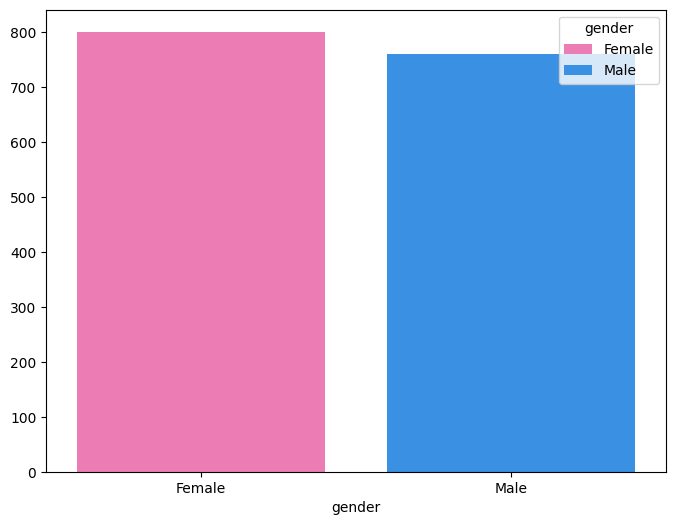

In [434]:
# When I changed the gender from int to str i can "play" with the data in a graph format
gender_count = df_employee_copy['gender'].value_counts()

plt.figure(figsize=(8, 6))
graph = sns.barplot(
    x=gender_count.index, 
    y=gender_count.values, 
    hue=gender_count.index,
    palette=['#FF69B4', '#1E90FF'], 
    legend=True
)
plt.show()

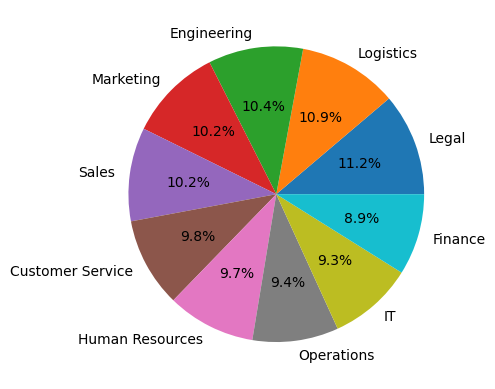

In [435]:
# In this case I wanted to plot the ratio of employees by department
employee_by_department = df_employee_copy['departmentID'].value_counts()
labels = df_employee_copy['departmentID'].unique()
plt.pie(employee_by_department, labels=labels, autopct='%1.1f%%')
plt.show()

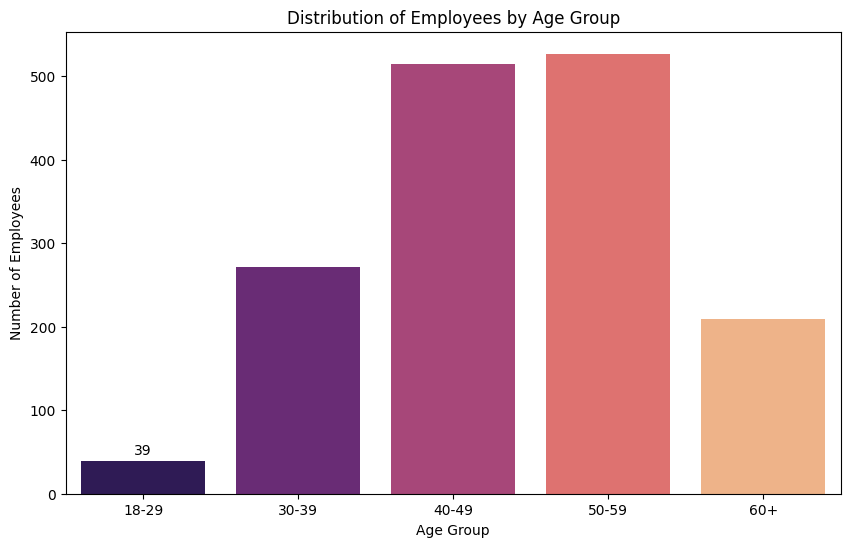

In [436]:
# On this cell I tried to create an age comparasion, to understand the major age group inside the company
from datetime import date
age = date.today().year - df_employee_copy['date_of_birth'].dt.year

bins = [18, 30, 40, 50, 60, 100]
labels = ['18-29', '30-39', '40-49', '50-59', '60+']
age_group = pd.cut(age, bins=bins, labels=labels) # This pandas method cut literally converts age to age range

age_dist = age_group.value_counts().reindex(labels)

plt.figure(figsize=(10, 6))
graph = sns.barplot(x=age_dist.index, y=age_dist.values, hue=age_dist.index, palette='magma', legend=False)
graph.bar_label(graph.containers[0], padding=3)

plt.title('Distribution of Employees by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Employees')
plt.show()

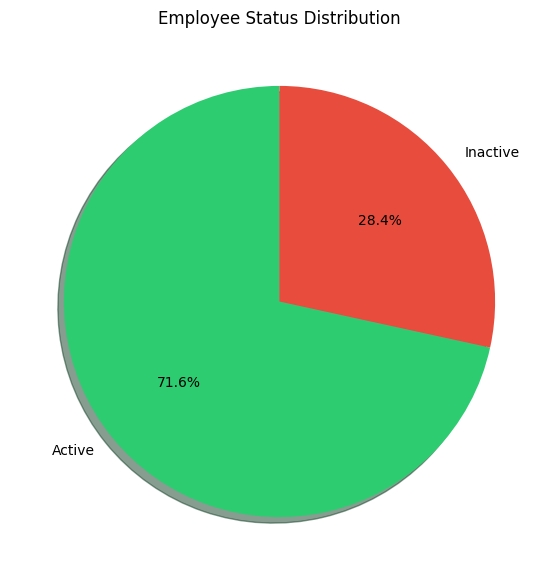

In [439]:
# Now let's see how many employees are actives and how many are not
status = np.where(df_employee_copy['termination_date'].isnull(), 'Active', 'Inactive')
status_counts = pd.Series(status).value_counts()

plt.figure(figsize=(7, 7))
plt.pie(
    status_counts.values, 
    labels=status_counts.index, 
    autopct='%1.1f%%',
    startangle=90,
    colors=['#2ECC71', '#E74C3C'],
    shadow=True
)

plt.title('Employee Status Distribution')
plt.show()

In [440]:
# Now we are goingo to the Action DataFrame
df_action_copy.head(4)

,ActID,ActionID,EmpID,EffectiveDt
0,1,10,1,01/Jan/2015
1,2,10,2,01/Jan/2015
2,3,10,3,06/Oct/2015
3,4,10,4,01/Jan/2015


In [442]:
# First as always we convert the date from string to datetime
df_action_copy['EffectiveDt'] = df_action_copy['EffectiveDt'].apply(pd.to_datetime, errors='coerce')
df_action_copy.head(5)

,ActID,ActionID,EmpID,EffectiveDt
0,1,10,1,2015-01-01
1,2,10,2,2015-01-01
2,3,10,3,2015-10-06
3,4,10,4,2015-01-01
4,5,10,5,2015-05-22


In [443]:
# After that, we change the columns names
df_action_copy = df_action_copy.rename(columns={
    'ActID': 'activityID',
    'ActionID': 'actionID',
    'EmpID': 'employeeID',
    'EffectiveDt': 'effective_date' 
})
df_action_copy

,activityID,actionID,employeeID,effective_date
0,1,10,1,2015-01-01
1,2,10,2,2015-01-01
2,3,10,3,2015-10-06
3,4,10,4,2015-01-01
4,5,10,5,2015-05-22
...,...,...,...,...
2581,2582,30,869,2023-05-16
2582,2583,30,1024,2023-08-17
2583,2584,30,1220,2023-08-10
2584,2585,30,1279,2023-03-24


In [451]:
df_action_copy.groupby('actionID')['actionID'].count()

actionID
10    1562
30     488
90     271
91     265
Name: actionID, dtype: int64